# 🏦 Credit Risk Assessment Using Machine Learning

## Predicting Loan Defaults with the LendingClub Dataset (2014-2018)

---

**Objective:** Build a binary classification model to predict whether a borrower will default on a loan, using historical lending data from LendingClub.

**Dataset:** LendingClub loan records (2014–2018), containing over 2 million records with 150+ features covering borrower demographics, credit history, and loan characteristics.

**Approach:**
1. Exploratory Data Analysis (EDA)
2. Data Cleaning & Preprocessing
3. Feature Engineering
4. Class Balancing Strategy
5. Model Training & Comparison (Logistic Regression, Random Forest, XGBoost, LightGBM)
6. Threshold Tuning & Evaluation
7. Feature Importance & Bias Analysis

---
## 1. Environment Setup & Library Imports

We begin by importing the core libraries for data manipulation, visualization, and machine learning.

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve
)
import xgboost as xgb
import lightgbm as lgb
import time
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Data Loading & Initial Inspection

Let's load the LendingClub dataset and take a first look at its structure.

In [3]:
# Load the dataset
file_path = 'loan_2014_18.csv'
df = pd.read_csv(file_path, low_memory=False)

print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 2,029,952
Total Columns: 142


In [4]:
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0,120122535,12000.000,12000.000,12000.000,36 months,7.97%,375.880,A,A5,associate,10+ years,OWN,42000.000,Source Verified,2017-09-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,923xx,CA,27.740,0.000,Jun-1996,715.000,719.000,0.000,NaN,80.000,9.000,1.000,11457.000,37%,16.000,w,0.000,0.000,13500.440,13500.440,12000.000,1500.440,0.000,0.000,0.000,May-2020,2591.950,NaN,May-2020,694.000,690.000,0.000,NaN,1.000,Individual,NaN,NaN,NaN,0.000,0.000,30502.000,1.000,2.000,1.000,3.000,8.000,19045.000,73.000,2.000,4.000,7117.000,53.000,31000.000,1.000,1.000,2.000,7.000,3389.000,7144.000,53.900,0.000,0.000,131.000,255.000,1.000,1.000,0.000,14.000,NaN,8.000,NaN,0.000,2.000,6.000,2.000,2.000,7.000,7.000,9.000,6.000,9.000,0.000,0.000,0.000,3.000,100.000,0.000,1.000,0.000,57180.000,30502.000,15500.000,26180.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,1,119374887,32000.000,32000.000,32000.000,36 months,11.99%,1062.710,B,B5,Nurse,10+ years,MORTGAGE,155000.000,Source Verified,2017-09-01,Current,n,https://lendingclub.com/browse/loanDetail.acti...,credit_card,Credit card refinancing,080xx,NJ,12.350,2.000,Sep-2005,715.000,719.000,1.000,10.000,NaN,20.000,0.000,48309.000,34.1%,42.000,w,6158.890,6158.890,31838.670,31838.670,25841.110,5997.560,0.000,0.000,0.000,May-2020,0.000,Jul-2020,May-2020,674.000,670.000,0.000,NaN,1.000,Individual,NaN,NaN,NaN,0.000,0.000,405751.000,2.000,1.000,1.000,1.000,8.000,15582.000,78.000,4.000,7.000,14049.000,40.000,142600.000,0.000,2.000,2.000,8.000,22542.000,81313.000,34.500,0.000,0.000,91.000,144.000,1.000,1.000,3.000,1.000,24.000,1.000,10.000,0.000,7.000,10.000,12.000,27.000,3.000,18.000,36.000

### 2.1 Missing Values Overview

Understanding the extent of missing data is crucial before any preprocessing.

In [5]:
# Calculate missing values
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

print(f"Columns with missing values: {len(missing_data)}/{df.shape[1]}")
print(f"Total missing values: {df.isnull().sum().sum():,}")

if len(missing_data) > 0:
    print("\nTop 20 columns with missing values:")
    print(missing_data.head(20).to_string(index=False))

Columns with missing values: 69/142
Total missing values: 74,698,339

Top 20 columns with missing values:
                                    Column  Missing_Count  Missing_Percentage
                      hardship_loan_status        1956776              96.395
                           hardship_reason        1956678              96.390
                           hardship_status        1956677              96.390
                              hardship_dpd        1956675              96.390
                       hardship_start_date        1956674              96.390
                             hardship_type        1956674              96.390
                           hardship_length        1956674              96.390
                   payment_plan_start_date        1956674              96.390
                         hardship_end_date        1956674              96.390
                             deferral_term        1956674              96.390
orig_projected_additional_accrued_in

---
## 3. Target Variable Analysis

The `loan_status` column contains the outcome of each loan. We need to inspect its distribution and then convert it into a binary classification target.

### 3.1 Original Loan Status Distribution

In [6]:
target_col = 'loan_status'
print(f"Unique values in '{target_col}':")
print(df[target_col].value_counts())
print(f"\nValue distribution (%):")
print(df[target_col].value_counts(normalize=True) * 100)

Unique values in 'loan_status':
loan_status
Fully Paid            1239089
Current                460148
Charged Off            313664
Late (31-120 days)       9532
In Grace Period          5644
Late (16-30 days)        1522
Default                   353
Name: count, dtype: int64

Value distribution (%):
loan_status
Fully Paid           61.040
Current              22.668
Charged Off          15.452
Late (31-120 days)    0.470
In Grace Period       0.278
Late (16-30 days)     0.075
Default               0.017
Name: proportion, dtype: float64


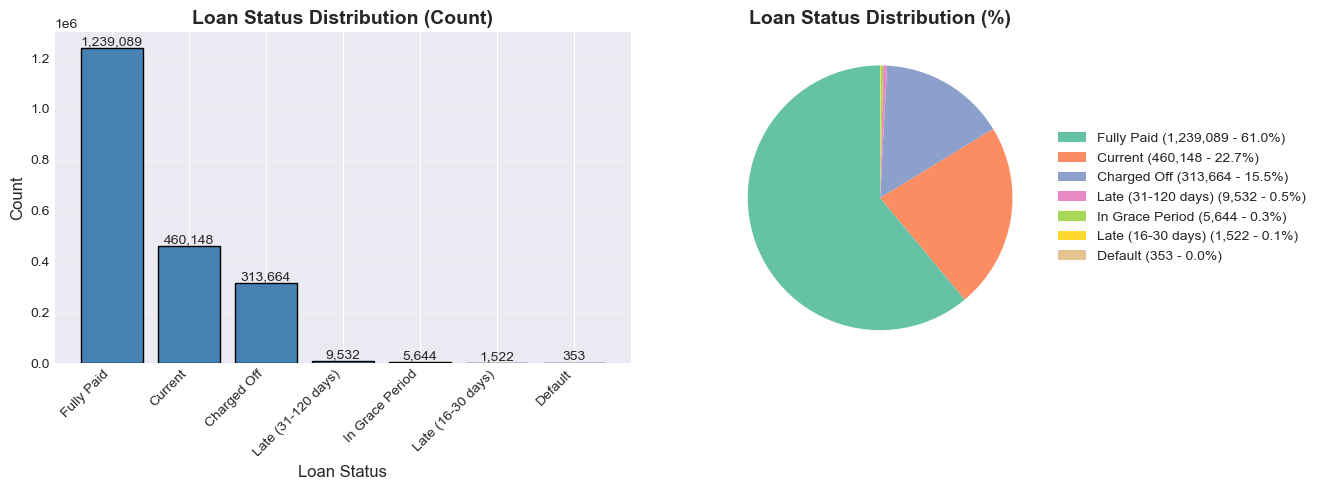

In [7]:
if target_col in df.columns:
    plt.figure(figsize=(14, 5))

    # Bar chart
    plt.subplot(1, 2, 1)
    target_counts = df[target_col].value_counts()
    plt.bar(range(len(target_counts)), target_counts.values, color='steelblue', edgecolor='black')
    plt.xticks(range(len(target_counts)), target_counts.index, rotation=45, ha='right')
    plt.xlabel('Loan Status', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title('Loan Status Distribution (Count)', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    for i, v in enumerate(target_counts.values):
        plt.text(i, v + max(target_counts.values) * 0.01, f'{v:,}', ha='center', fontsize=10)

    # Pie chart
    plt.subplot(1, 2, 2)
    colors = sns.color_palette("Set2", len(target_counts))
    plt.pie(target_counts.values, startangle=90, colors=colors)
    total = sum(target_counts.values)
    legend_labels = [f'{label} ({count:,} - {count/total*100:.1f}%)'
                     for label, count in target_counts.items()]
    plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)
    plt.title('Loan Status Distribution (%)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

### 3.2 Binary Target Creation

We group the loan statuses into two categories:
- **Good Loan (0):** Fully Paid, Current, In Grace Period, Late (16-30 days), Late (31-120 days)
- **Bad Loan (1):** Charged Off, Default

In [13]:
# Define good and bad loan categories
good_loan_status = ['Fully Paid', 'Current', 'In Grace Period',
                    'Late (16-30 days)', 'Late (31-120 days)']
bad_loan_status = ['Charged Off', 'Default']

# Create binary target variable
df['loan_status_binary'] = df['loan_status'].apply(
    lambda x: 0 if x in good_loan_status else 1
)
df['loan_status_label'] = df['loan_status_binary'].map({
    0: 'Good Loan',
    1: 'Bad Loan (Default)'
})

print("Binary target distribution:")
print(df['loan_status_label'].value_counts())
print("\nPercentage distribution:")
print(df['loan_status_label'].value_counts(normalize=True) * 100)

default_rate = (df['loan_status_binary'].sum() / len(df)) * 100
print(f"\nOverall Default Rate: {default_rate:.2f}%")

Binary target distribution:
loan_status_label
Good Loan             1715935
Bad Loan (Default)     314017
Name: count, dtype: int64

Percentage distribution:
loan_status_label
Good Loan            84.531
Bad Loan (Default)   15.469
Name: proportion, dtype: float64

Overall Default Rate: 15.47%


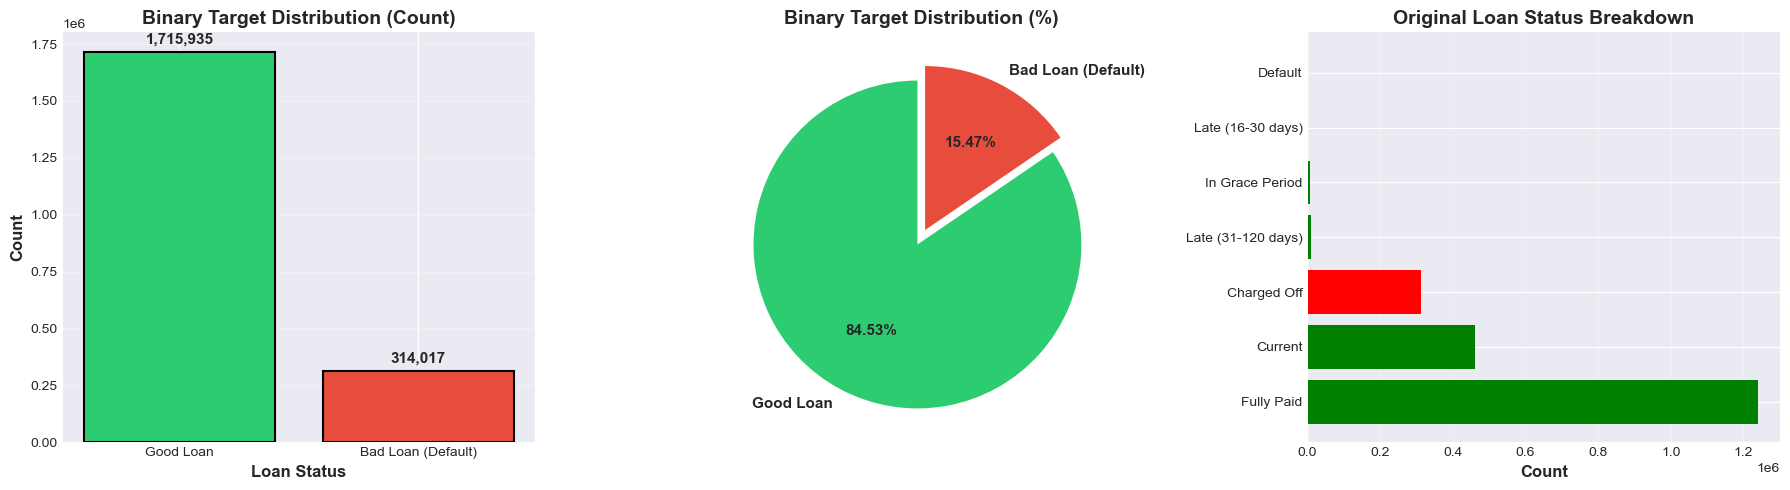

In [14]:
# Visualize the binary target variable
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
target_counts = df['loan_status_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Loan Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Binary Target Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + max(target_counts.values) * 0.02, f'{v:,}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.2f%%',
            startangle=90, colors=colors, explode=(0.05, 0.05),
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Binary Target Distribution (%)', fontsize=14, fontweight='bold')

original_counts = df['loan_status'].value_counts()
axes[2].barh(original_counts.index, original_counts.values,
             color=['green' if s in good_loan_status else 'red' for s in original_counts.index])
axes[2].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[2].set_title('Original Loan Status Breakdown', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Class Imbalance Check

In [18]:
good_loans = (df['loan_status_binary'] == 0).sum()
bad_loans = (df['loan_status_binary'] == 1).sum()
imbalance_ratio = good_loans / bad_loans

print(f"Good Loans: {good_loans:,} ({good_loans/len(df)*100:.2f}%)")
print(f"Bad Loans: {bad_loans:,} ({bad_loans/len(df)*100:.2f}%)")
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

Good Loans: 1,715,935 (84.53%)
Bad Loans: 314,017 (15.47%)

Imbalance Ratio: 5.46:1


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Feature Categorization

In [21]:
# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Total numerical columns: {len(numerical_cols)}")

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Total categorical columns: {len(categorical_cols)}")

Total numerical columns: 109
Total categorical columns: 35


### 4.2 Key Feature Selection & Distribution Analysis

In [23]:
# Select key numerical features for analysis
key_numerical_features = ['loan_amnt', 'annual_inc', 'dti', 'fico_range_low',
                          'revol_bal', 'installment', 'open_acc', 'total_acc']
key_numerical_features = [f for f in key_numerical_features if f in df.columns]

print(df[key_numerical_features].describe().T)

                     count      mean        std      min       25%       50%  \
loan_amnt      2029952.000 15194.073   9295.733 1000.000  8000.000 13000.000   
annual_inc     2029952.000 78711.860 117488.725    0.000 46800.000 65000.000   
dti            2028241.000    19.102     14.723   -1.000    12.040    18.050   
fico_range_low 2029952.000   698.450     33.139  660.000   675.000   690.000   
revol_bal      2029952.000 16739.446  23274.453    0.000  5891.000 11262.000   
installment    2029952.000   448.570    269.803    7.610   252.400   378.470   
open_acc       2029952.000    11.717      5.735    0.000     8.000    11.000   
total_acc      2029952.000    24.170     12.073    2.000    15.000    22.000   

                     75%           max  
loan_amnt      20000.000     40000.000  
annual_inc     95000.000 110000000.000  
dti               24.840       999.000  
fico_range_low   715.000       845.000  
revol_bal      20260.000   2904836.000  
installment      597.780      171

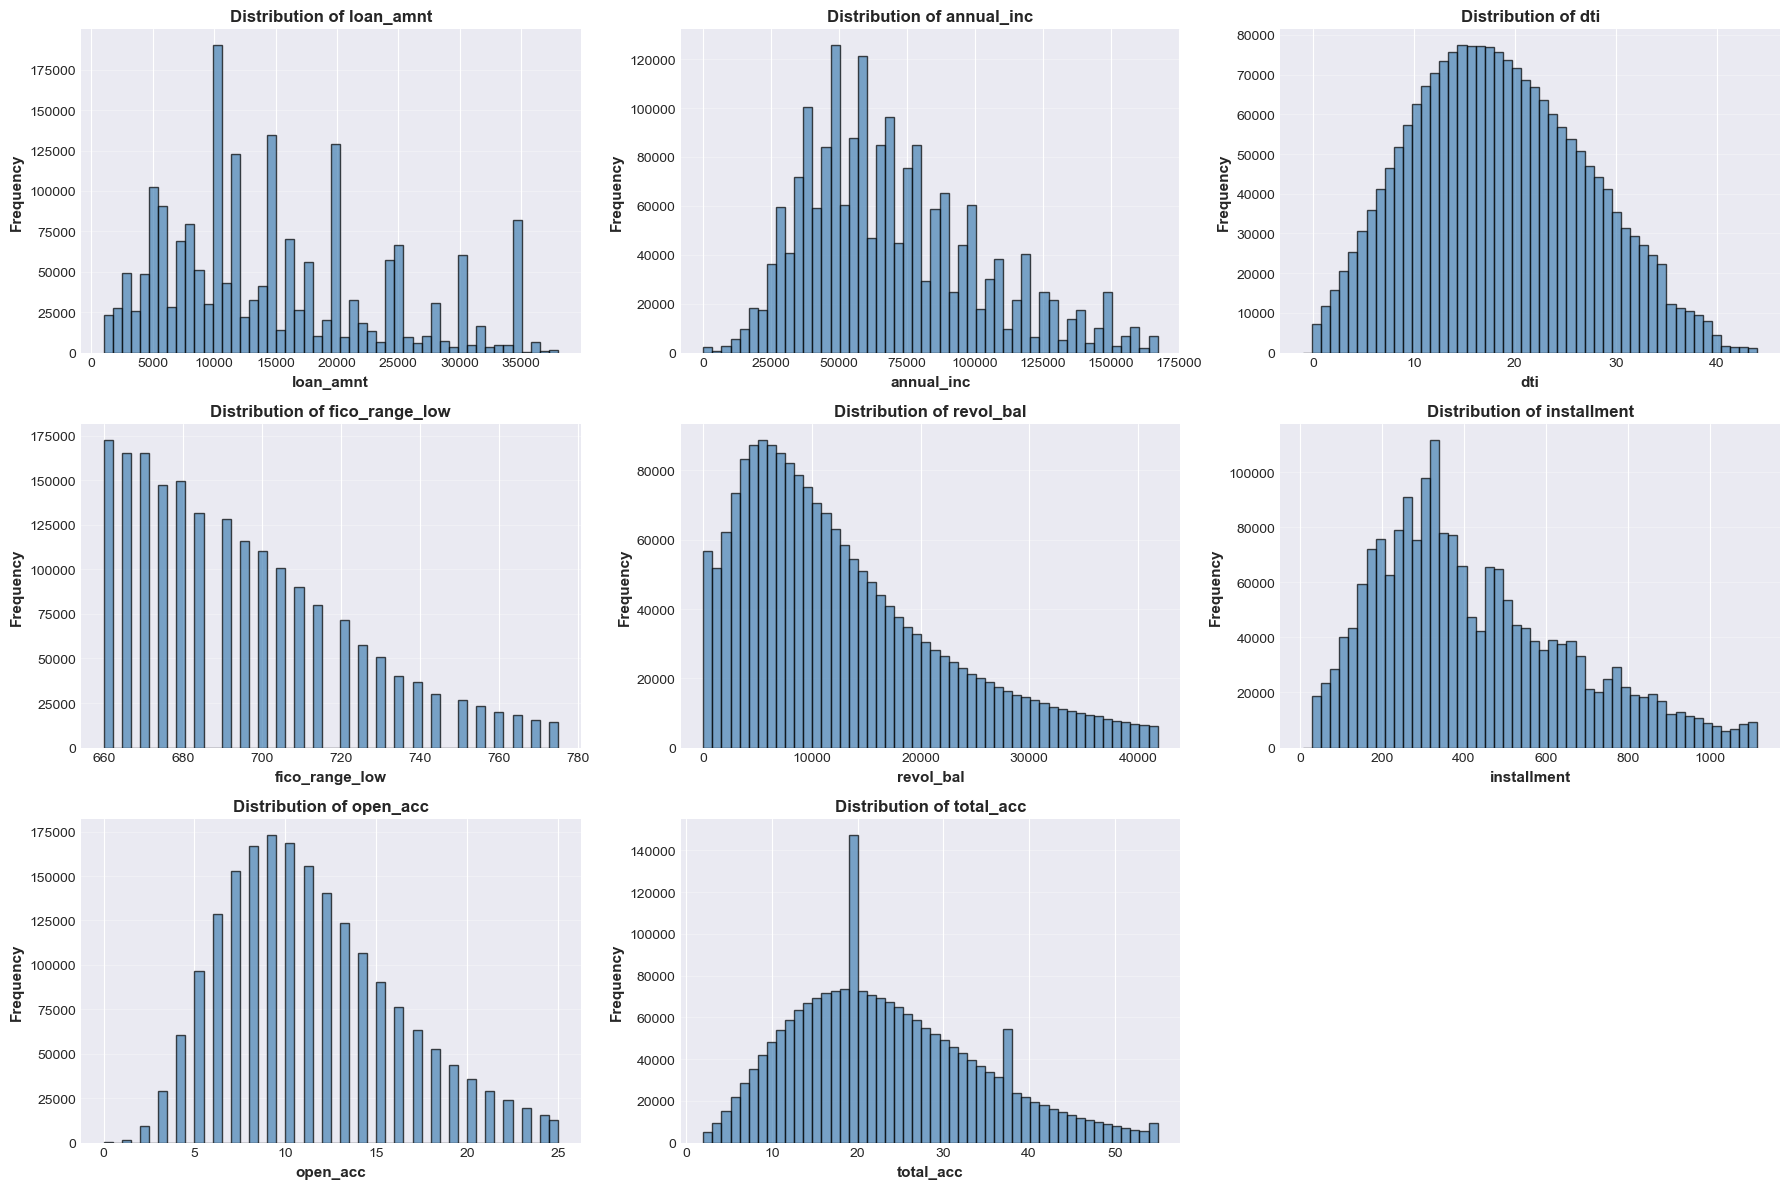

In [26]:
# Visualize distributions of key numerical features
n_features = len(key_numerical_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for idx, feature in enumerate(key_numerical_features):
    Q1, Q3 = df[feature].quantile(0.25), df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    filtered_data = df[feature][(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

    axes[idx].hist(filtered_data.dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 4.3 Categorical Feature Analysis

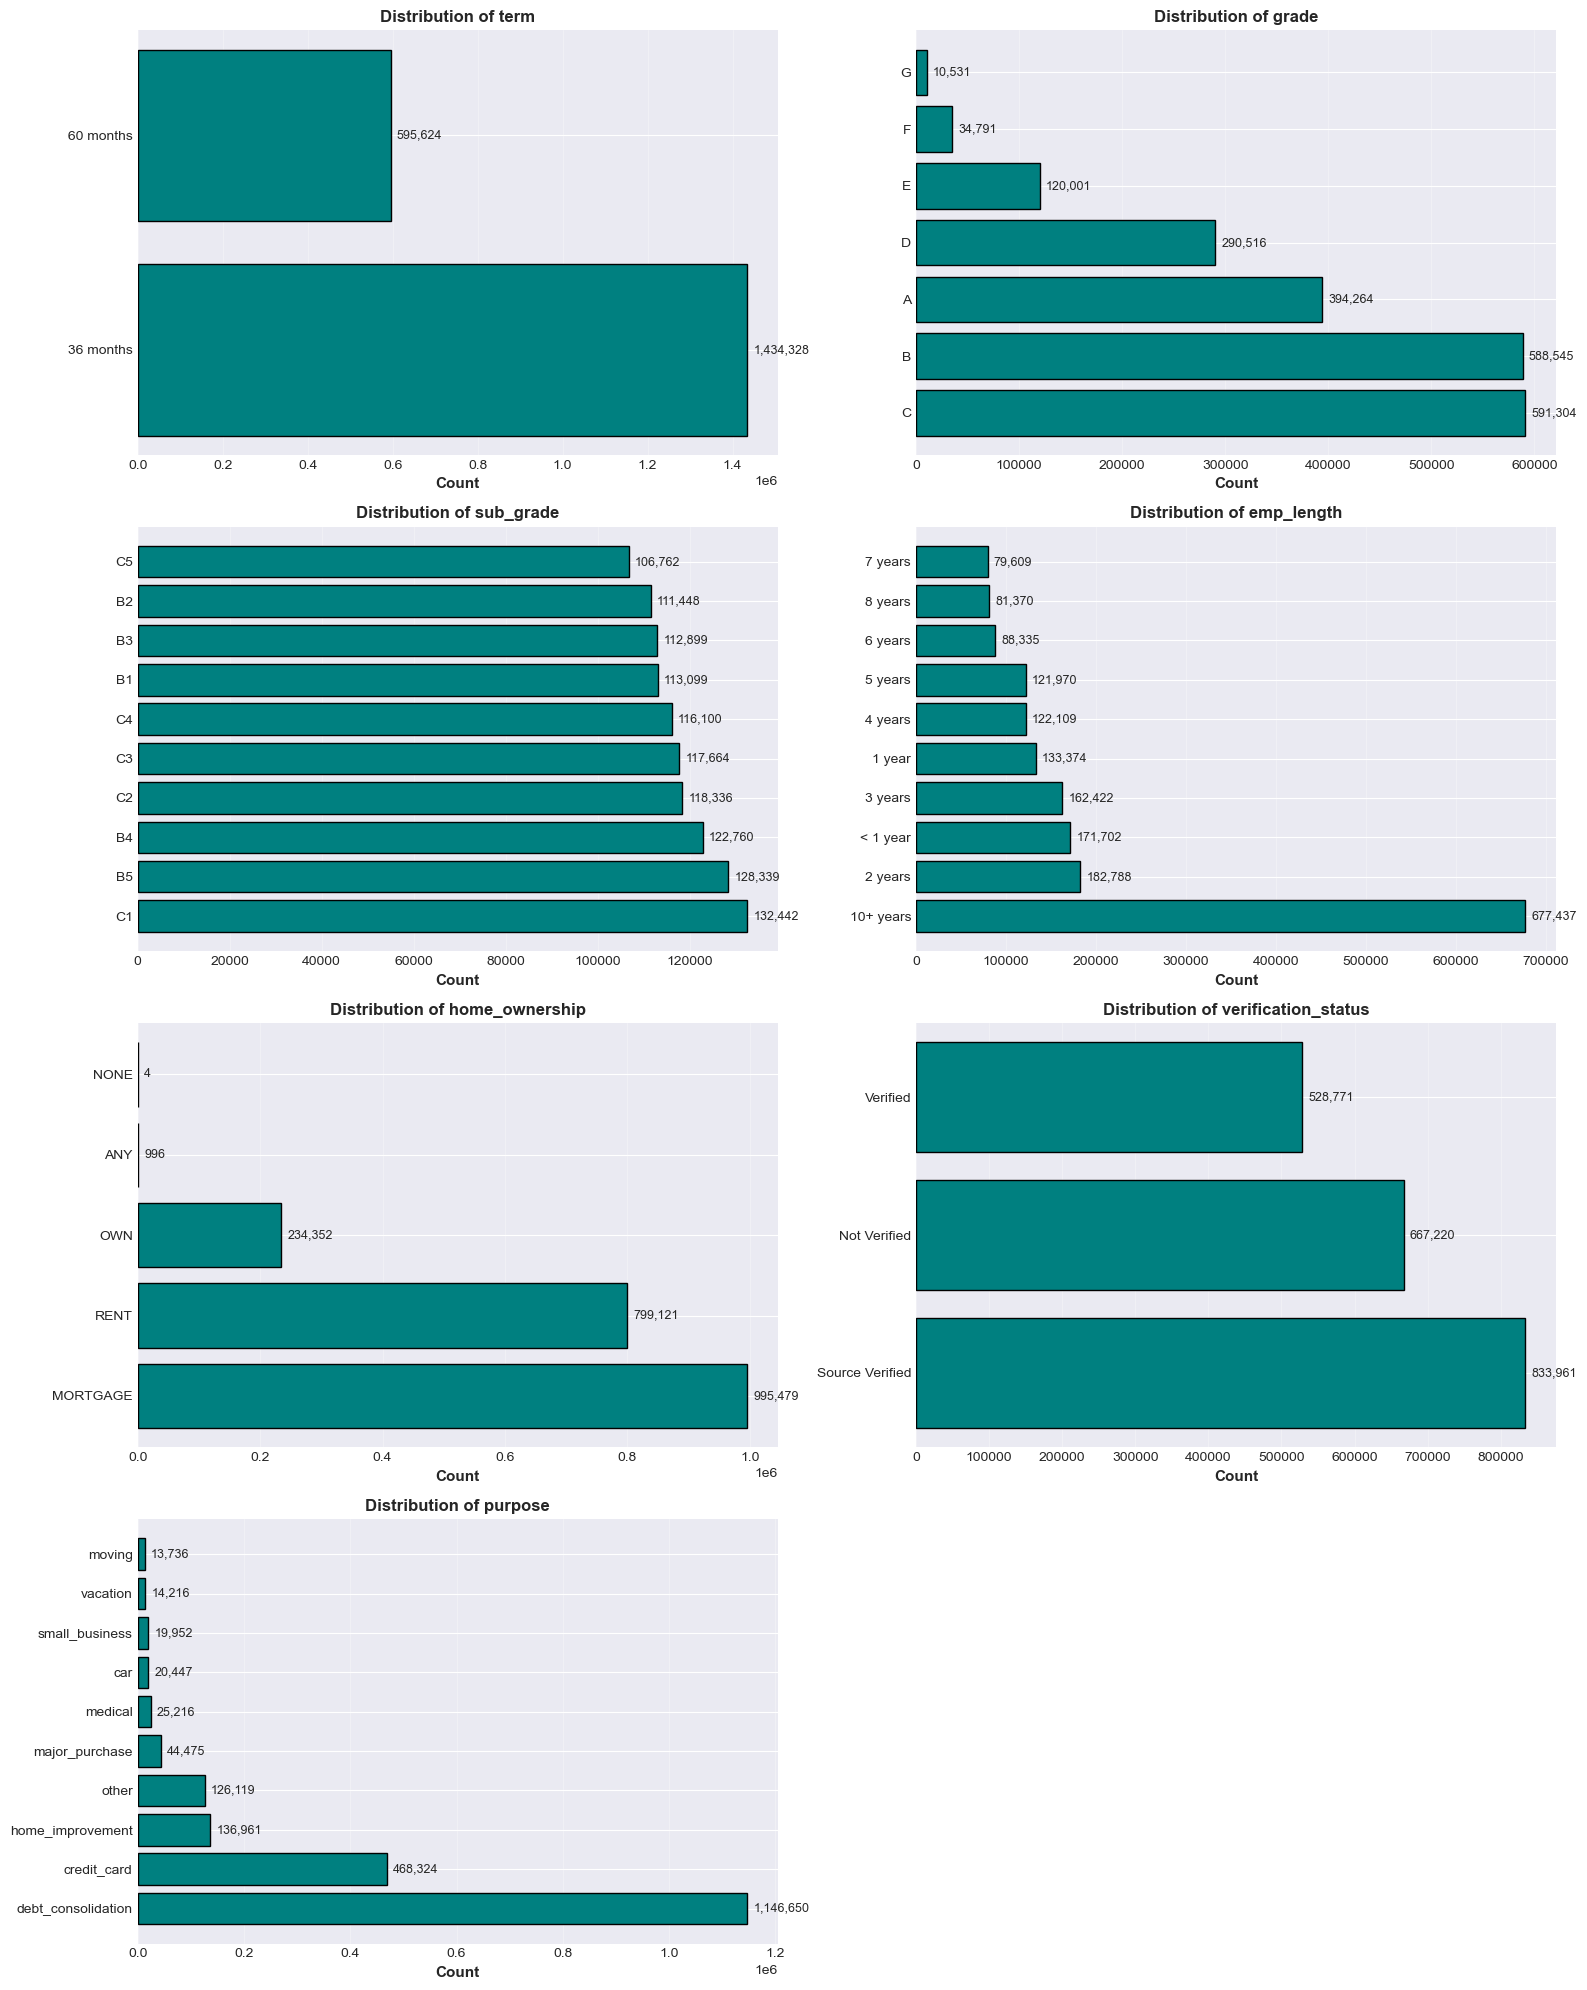

In [28]:
# Select key categorical features
key_categorical_features = ['term', 'grade', 'sub_grade', 'emp_length',
                            'home_ownership', 'verification_status', 'purpose']
key_categorical_features = [f for f in key_categorical_features if f in df.columns]

# Visualize key categorical features
n_features = len(key_categorical_features)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for idx, feature in enumerate(key_categorical_features):
    value_counts = df[feature].value_counts().head(10)
    axes[idx].barh(range(len(value_counts)), value_counts.values, color='teal', edgecolor='black')
    axes[idx].set_yticks(range(len(value_counts)))
    axes[idx].set_yticklabels(value_counts.index)
    axes[idx].set_xlabel('Count', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    for i, v in enumerate(value_counts.values):
        axes[idx].text(v + max(value_counts.values) * 0.01, i, f'{v:,}', va='center', fontsize=9)

for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### 4.4 Feature vs Target Analysis

How do features differ between good and bad loans?

In [32]:
# Numerical features: compare means
comparison_data = []
for feature in key_numerical_features:
    good_mean = df[df['loan_status_binary'] == 0][feature].mean()
    bad_mean = df[df['loan_status_binary'] == 1][feature].mean()
    diff_pct = ((bad_mean - good_mean) / good_mean) * 100
    comparison_data.append({
        'Feature': feature,
        'Good Loans (Mean)': good_mean,
        'Bad Loans (Mean)': bad_mean,
        'Difference (%)': diff_pct
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

       Feature  Good Loans (Mean)  Bad Loans (Mean)  Difference (%)
     loan_amnt          15051.821         15971.400           6.109
    annual_inc          79885.724         72297.320          -9.499
           dti             18.844            20.515           8.872
fico_range_low            700.179           689.003          -1.596
     revol_bal          17017.157         15221.900         -10.550
   installment            443.857           474.327           6.865
      open_acc             11.670            11.972           2.591
     total_acc             24.141            24.326           0.765


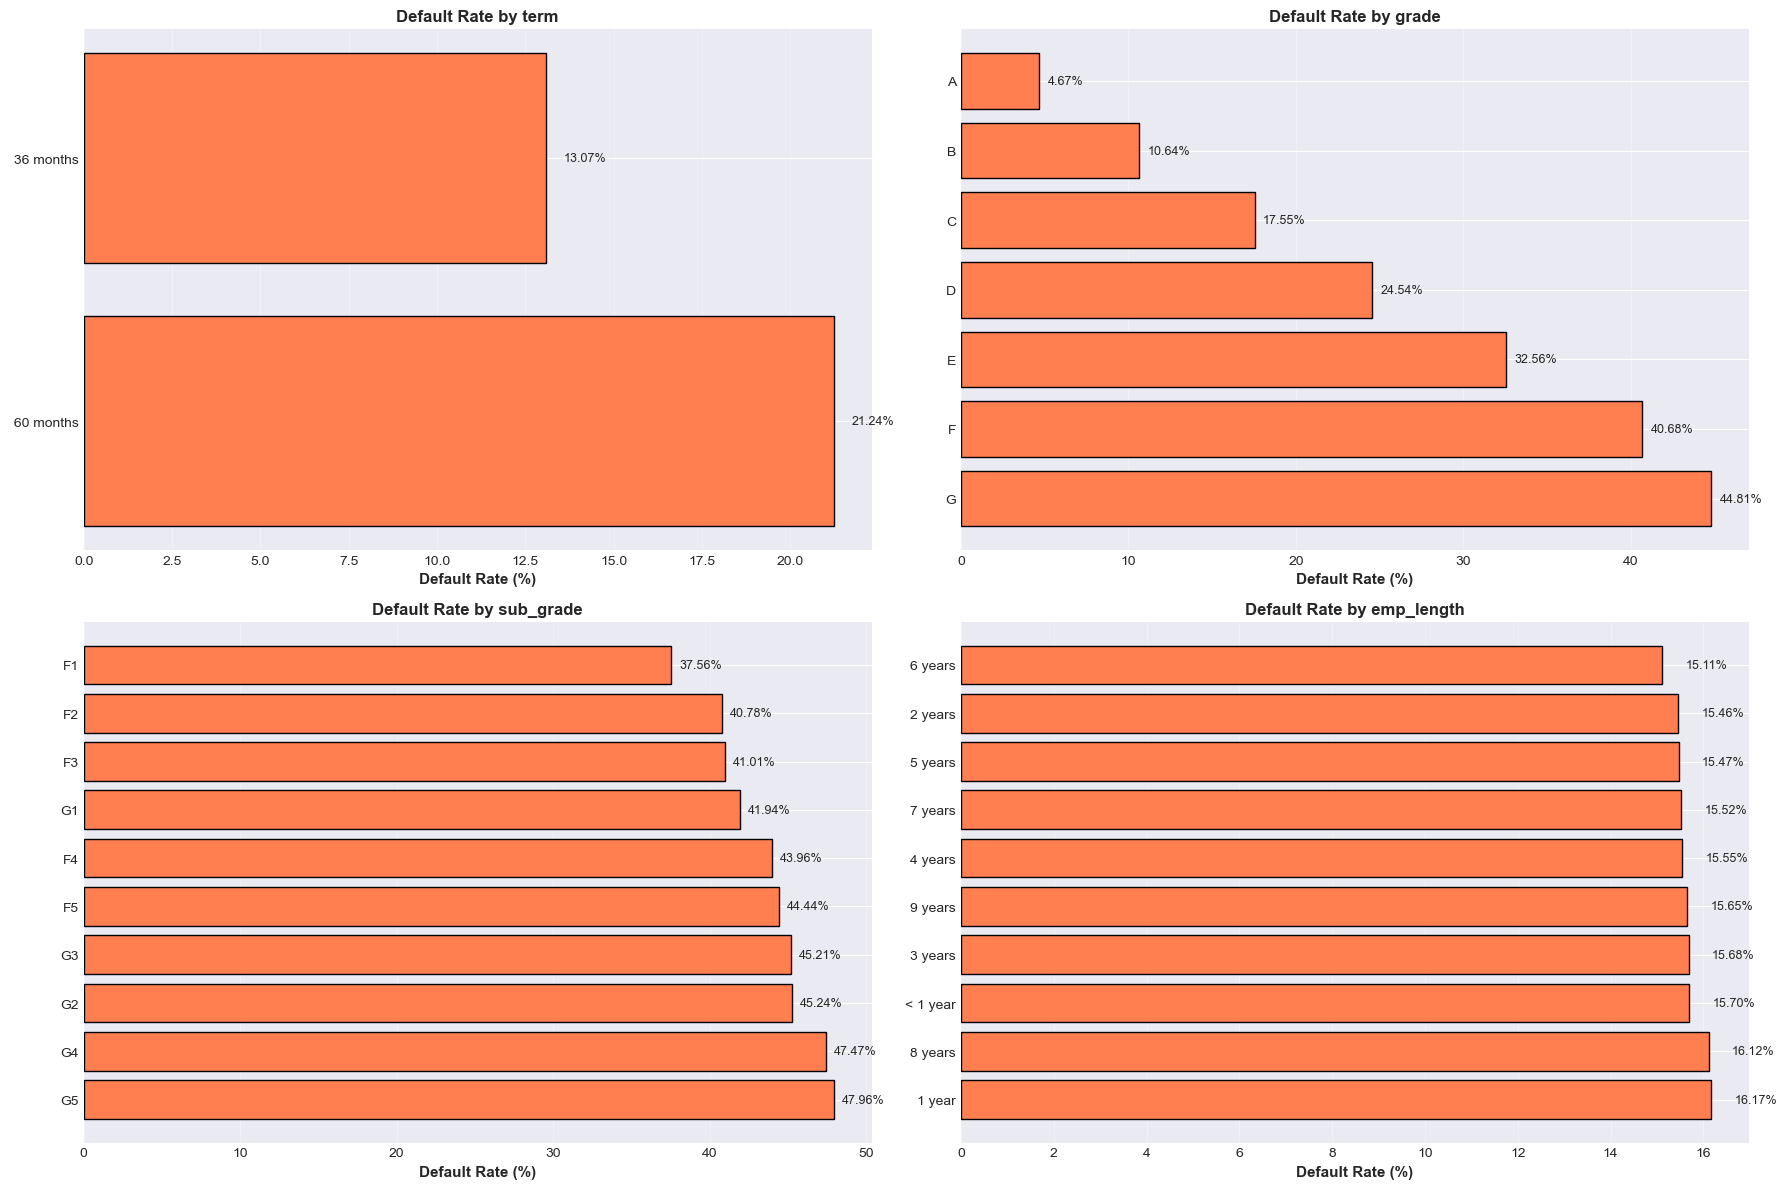

In [34]:
# Default rate by categorical features
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(key_categorical_features[:4]):
    default_rate = df.groupby(feature)['loan_status_binary'].agg([
        ('count', 'count'),
        ('default_rate', lambda x: (x.sum() / len(x)) * 100)
    ]).sort_values('default_rate', ascending=False).head(10)

    axes[idx].barh(range(len(default_rate)), default_rate['default_rate'], color='coral', edgecolor='black')
    axes[idx].set_yticks(range(len(default_rate)))
    axes[idx].set_yticklabels(default_rate.index)
    axes[idx].set_xlabel('Default Rate (%)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Default Rate by {feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    for i, v in enumerate(default_rate['default_rate']):
        axes[idx].text(v + 0.5, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 4.5 Correlation Analysis

Correlation with Target Variable (loan_status_binary):
------------------------------------------------------------
loan_status_binary    1.000
dti                   0.041
installment           0.041
loan_amnt             0.036
open_acc              0.019
total_acc             0.006
annual_inc           -0.023
revol_bal            -0.028
fico_range_low       -0.122
Name: loan_status_binary, dtype: float64


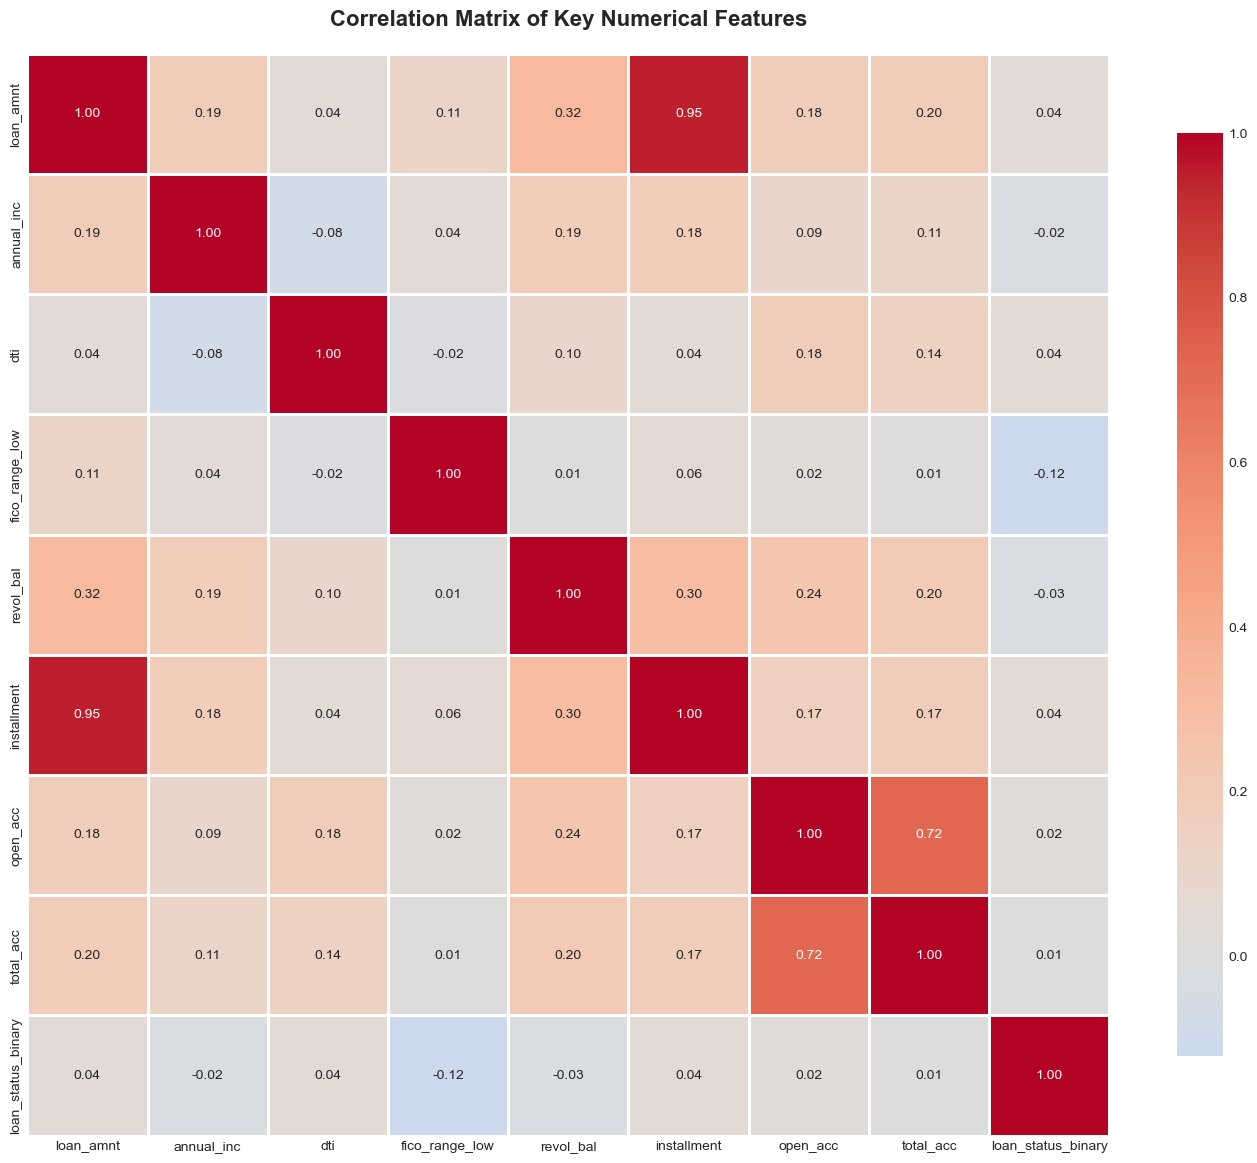

In [37]:
# Correlation matrix for numerical features
features_for_correlation = key_numerical_features + ['loan_status_binary']
correlation_matrix = df[features_for_correlation].corr()

print("Correlation with Target Variable (loan_status_binary):")
print("-" * 60)
print(correlation_matrix['loan_status_binary'].sort_values(ascending=False))

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Key Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## 5. Data Cleaning & Preprocessing

### 5.1 Removing Unnecessary Columns

We remove columns that are:
- **ID columns:** Not useful for prediction
- **High missing (>50%):** Too sparse to be informative
- **Post-loan columns:** Cause data leakage (only available after the loan is issued)
- **Redundant columns:** Duplicated or uninformative

In [40]:
# Identify columns to remove
columns_to_remove = []

# 1. ID columns
id_columns = ['Unnamed: 0', 'id', 'member_id', 'url']
columns_to_remove.extend([col for col in id_columns if col in df.columns])

# 2. Columns with >50% missing values
high_missing_cols = missing_data[missing_data['Missing_Percentage'] > 50]['Column'].tolist()
columns_to_remove.extend(high_missing_cols)

# 3. Post-loan columns (DATA LEAKAGE!)
post_loan_columns = [
    'funded_amnt', 'funded_amnt_inv', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq',
    'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'issue_d'
]
columns_to_remove.extend([col for col in post_loan_columns if col in df.columns])

# 4. Redundant columns
redundant_columns = ['emp_title', 'title', 'zip_code', 'pymnt_plan']
columns_to_remove.extend([col for col in redundant_columns if col in df.columns])

# 5. Original loan_status (we have the binary version)
if 'loan_status' in df.columns:
    columns_to_remove.append('loan_status')

columns_to_remove = list(set(columns_to_remove))

# Apply removal
df_clean = df.drop(columns=columns_to_remove, errors='ignore')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print(f"Columns removed: {df.shape[1] - df_clean.shape[1]}")

Original shape: (2029952, 144)
Cleaned shape:  (2029952, 80)
Columns removed: 64


### 5.2 Type Conversions

Some numerical features are stored as strings (e.g., `revol_util`, `int_rate`, `term`). We convert them to proper numeric types.

In [43]:
# Convert revol_util from string to float (remove % sign)
if 'revol_util' in df_clean.columns and df_clean['revol_util'].dtype == 'object':
    df_clean['revol_util'] = df_clean['revol_util'].str.replace('%', '').replace('', np.nan)
    df_clean['revol_util'] = pd.to_numeric(df_clean['revol_util'], errors='coerce')
    print("revol_util converted to numeric")

# Convert int_rate from string to float (remove % sign)
if 'int_rate' in df_clean.columns and df_clean['int_rate'].dtype == 'object':
    df_clean['int_rate'] = df_clean['int_rate'].str.replace('%', '').replace('', np.nan)
    df_clean['int_rate'] = pd.to_numeric(df_clean['int_rate'], errors='coerce')
    print("int_rate converted to numeric")

# Convert term to numeric (extract number of months)
if 'term' in df_clean.columns and df_clean['term'].dtype == 'object':
    df_clean['term'] = df_clean['term'].str.extract('(\d+)').astype(float)
    print("term converted to numeric (months)")

revol_util converted to numeric
int_rate converted to numeric
term converted to numeric (months)


### 5.3 Missing Value Imputation

Different strategies for different types of features:
- **Credit history features:** Fill with 999 (indicates "no history")
- **Numerical features:** Fill with median
- **Categorical features:** Fill with mode or "Unknown"
- **Low missing (<5%):** Drop remaining rows

In [45]:
# 1. Credit history features - missing means "no history"
credit_history_cols = [
    'mths_since_last_delinq', 'mths_since_last_record',
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq'
]
for col in credit_history_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(999, inplace=True)

# 2. Numerical features - fill with median
numerical_cols_to_impute = ['annual_inc', 'dti', 'revol_util', 'bc_open_to_buy',
                            'bc_util', 'mo_sin_old_il_acct', 'mths_since_recent_inq',
                            'num_tl_120dpd_2m', 'percent_bc_gt_75', 'tot_hi_cred_lim']
for col in numerical_cols_to_impute:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# 3. Categorical features - fill with mode
categorical_cols_to_impute = ['emp_length']
for col in categorical_cols_to_impute:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
        df_clean[col].fillna(mode_val, inplace=True)

# 4. Drop rows with remaining missing values (<5% missing columns)
remaining_missing = df_clean.columns[df_clean.isnull().any()].tolist()
if remaining_missing:
    missing_pct = (df_clean[remaining_missing].isnull().sum() / len(df_clean)) * 100
    cols_to_drop_rows = missing_pct[missing_pct < 5].index.tolist()
    if cols_to_drop_rows:
        before_drop = len(df_clean)
        df_clean = df_clean.dropna(subset=cols_to_drop_rows)
        print(f"Rows dropped: {before_drop - len(df_clean):,}")

print(f"Remaining missing values: {df_clean.isnull().sum().sum():,}")
print(f"Current dataframe shape: {df_clean.shape}")

Rows dropped: 21,265
Remaining missing values: 9,120,162
Current dataframe shape: (2008687, 80)


### 5.4 Outlier Analysis

Using the IQR method (3x IQR for extreme outliers) and capping outliers at the 1st and 99th percentiles.

In [47]:
# Identify numerical columns (excluding target)
numerical_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [col for col in numerical_features if col != 'loan_status_binary']

print(f"Analyzing outliers in {len(numerical_features)} numerical features...")

outlier_summary = []
for feature in numerical_features:
    Q1, Q3 = df_clean[feature].quantile(0.25), df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound, upper_bound = Q1 - 3 * IQR, Q3 + 3 * IQR
    outliers = df_clean[(df_clean[feature] < lower_bound) | (df_clean[feature] > upper_bound)][feature]
    outlier_pct = (len(outliers) / len(df_clean)) * 100
    if len(outliers) > 0:
        outlier_summary.append({
            'Feature': feature, 'Outlier_Count': len(outliers),
            'Outlier_Percentage': outlier_pct
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
print(f"\nFeatures with extreme outliers: {len(outlier_df)}")
print(outlier_df.head(15).to_string(index=False))

# Cap outliers at 1st and 99th percentile
for feature in numerical_features:
    lower, upper = df_clean[feature].quantile(0.01), df_clean[feature].quantile(0.99)
    df_clean[feature] = df_clean[feature].clip(lower=lower, upper=upper)

print("\nOutliers capped at 1st and 99th percentiles.")

Analyzing outliers in 66 numerical features...

Features with extreme outliers: 62
              Feature  Outlier_Count  Outlier_Percentage
num_accts_ever_120_pd         469110              23.354
          delinq_2yrs         382828              19.059
              pub_rec         335001              16.678
 pub_rec_bankruptcies         252040              12.547
mths_since_recent_inq         222518              11.078
   num_tl_90g_dpd_24m         108778               5.415
 mths_since_recent_bc          96599               4.809
       bc_open_to_buy          66214               3.296
mo_sin_rcnt_rev_tl_op          64639               3.218
            tax_liens          62510               3.112
   mths_since_rcnt_il          62487               3.111
          open_act_il          55506               2.763
            revol_bal          48984               2.439
       mo_sin_rcnt_tl          46810               2.330
               inq_fi          46160               2.298

Outl

---
## 6. Feature Engineering

Creating new features from existing ones to capture additional signal.

In [49]:
# Credit Utilization Ratio
if 'revol_bal' in df_clean.columns and 'revol_util' in df_clean.columns:
    df_clean['credit_utilization'] = df_clean['revol_util']

# Income to Loan Ratio
if 'annual_inc' in df_clean.columns and 'loan_amnt' in df_clean.columns:
    df_clean['income_to_loan_ratio'] = df_clean['annual_inc'] / (df_clean['loan_amnt'] + 1)

# Installment to Income Ratio
if 'installment' in df_clean.columns and 'annual_inc' in df_clean.columns:
    df_clean['installment_to_income'] = (df_clean['installment'] * 12) / (df_clean['annual_inc'] + 1)

# FICO Average
if 'fico_range_low' in df_clean.columns and 'fico_range_high' in df_clean.columns:
    df_clean['fico_average'] = (df_clean['fico_range_low'] + df_clean['fico_range_high']) / 2

# Credit History Length (if earliest_cr_line exists)
if 'earliest_cr_line' in df_clean.columns:
    df_clean['earliest_cr_line'] = pd.to_datetime(df_clean['earliest_cr_line'], errors='coerce')
    df_clean['credit_history_years'] = (pd.Timestamp.now() - df_clean['earliest_cr_line']).dt.days / 365.25

print(f"Features after engineering: {df_clean.shape[1]}")

Features after engineering: 85


### 6.1 Categorical Encoding

Converting categorical features to numerical using Label Encoding.

In [52]:
# Identify categorical columns
categorical_columns = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_columns = [col for col in categorical_columns if col != 'loan_status_label']

print(f"Categorical columns to encode: {len(categorical_columns)}")

# Label encode
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

# Drop original categorical columns
columns_to_drop = ['home_ownership', 'verification_status', 'initial_list_status',
                   'purpose', 'addr_state', 'grade', 'sub_grade', 'emp_length',
                   'loan_status_label', 'loan_amount_category', 'earliest_cr_line']
df_model = df_clean.drop(columns=[col for col in columns_to_drop if col in df_clean.columns], errors='ignore')

# Drop FICO range columns (we have fico_average)
if 'fico_average' in df_model.columns:
    df_model = df_model.drop(columns=['fico_range_low', 'fico_range_high'], errors='ignore')

# Separate features and target
X = df_model.drop(columns=['loan_status_binary'], errors='ignore')
y = df_model['loan_status_binary']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Categorical columns to encode: 11

Feature matrix shape: (2008687, 83)
Target shape: (2008687,)


In [53]:
# Handle any remaining object columns
remaining_object_cols = X.select_dtypes(include=['object']).columns.tolist()
if remaining_object_cols:
    print(f"Found {len(remaining_object_cols)} remaining object columns, encoding...")
    for col in remaining_object_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

# Handle flag columns
flag_columns = ['application_type', 'hardship_flag', 'debt_settlement_flag']
for col in flag_columns:
    if col in X.columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

print(f"Final X shape: {X.shape}")

Found 3 remaining object columns, encoding...
Final X shape: (2008687, 83)


### 6.2 Feature Scaling

Standardizing numerical features to have zero mean and unit variance.

In [56]:
# Standard scaling
scaler = StandardScaler()
numerical_cols_to_scale = X.select_dtypes(include=[np.number]).columns.tolist()

X_scaled = X.copy()
X_scaled[numerical_cols_to_scale] = scaler.fit_transform(X[numerical_cols_to_scale])

print(f"Scaled {len(numerical_cols_to_scale)} numerical columns")

# Verify no missing values
print(f"\nMissing values in X:        {X.isnull().sum().sum()}")
print(f"Missing values in X_scaled: {X_scaled.isnull().sum().sum()}")

Scaled 83 numerical columns

Missing values in X:        9120162
Missing values in X_scaled: 9120162


> **Note:** If there are remaining missing values after the above steps, we handle them with additional imputation (median for numerical, indicator columns for high-missing features) before proceeding.

In [58]:
# Handle any remaining missing values
remaining_missing = X.columns[X.isnull().any()].tolist()
if remaining_missing:
    missing_analysis = pd.DataFrame({
        'Column': remaining_missing,
        'Missing_Count': X[remaining_missing].isnull().sum(),
        'Missing_Percentage': (X[remaining_missing].isnull().sum() / len(X)) * 100
    }).sort_values('Missing_Percentage', ascending=False)

    # High missing (>40%) - drop
    high_missing_cols = missing_analysis[missing_analysis['Missing_Percentage'] > 40]['Column'].tolist()
    if high_missing_cols:
        X = X.drop(columns=high_missing_cols)
        X_scaled = X_scaled.drop(columns=high_missing_cols)
        print(f"Dropped {len(high_missing_cols)} columns with >40% missing")

    # Remaining - fill with median
    for col in X.columns[X.isnull().any()]:
        if X[col].dtype in ['float64', 'int64', 'int32']:
            X[col].fillna(X[col].median(), inplace=True)
            X_scaled[col].fillna(X_scaled[col].median(), inplace=True)

print(f"Final missing values in X: {X.isnull().sum().sum()}")
print(f"Final missing values in X_scaled: {X_scaled.isnull().sum().sum()}")

Dropped 1 columns with >40% missing
Final missing values in X: 0
Final missing values in X_scaled: 0


---
## 7. Data Splitting & Class Balancing

### Strategy:
1. First, split 20% as a **test set** (preserving original imbalanced distribution)
2. From the remaining 80%, create a **balanced training set** with a 65:35 (good:bad) ratio
3. Split balanced data into 75% training / 25% validation

In [60]:
# Step 1: Separate test set (20%) - keeps original distribution
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Test set: {X_test.shape[0]:,} samples")
print(f"  Good Loans: {(y_test == 0).sum():,} ({(y_test == 0).sum()/len(y_test)*100:.2f}%)")
print(f"  Bad Loans:  {(y_test == 1).sum():,} ({(y_test == 1).sum()/len(y_test)*100:.2f}%)")

Test set: 401,738 samples
  Good Loans: 339,232 (84.44%)
  Bad Loans:  62,506 (15.56%)


In [61]:
# Step 2: Create balanced training set (65-35 ratio)
good_loans = X_temp[y_temp == 0]
bad_loans = X_temp[y_temp == 1]
y_good = y_temp[y_temp == 0]
y_bad = y_temp[y_temp == 1]

# Use ALL bad loans, sample good loans to achieve 65-35 balance
n_bad_loans = len(bad_loans)
total_samples = int(n_bad_loans / 0.35)
n_good_loans = min(int(total_samples * 0.65), len(good_loans))

good_sample_idx = np.random.RandomState(42).choice(len(good_loans), size=n_good_loans, replace=False)
good_loans_sampled = good_loans.iloc[good_sample_idx]
y_good_sampled = y_good.iloc[good_sample_idx]

# Combine and shuffle
X_balanced = pd.concat([good_loans_sampled, bad_loans], axis=0)
y_balanced = pd.concat([y_good_sampled, y_bad], axis=0)
shuffle_idx = np.random.RandomState(42).permutation(len(X_balanced))
X_balanced = X_balanced.iloc[shuffle_idx].reset_index(drop=True)
y_balanced = y_balanced.iloc[shuffle_idx].reset_index(drop=True)

print(f"\nBalanced dataset: {len(X_balanced):,} samples")
print(f"  Good Loans: {(y_balanced == 0).sum():,} ({(y_balanced == 0).mean()*100:.1f}%)")
print(f"  Bad Loans:  {(y_balanced == 1).sum():,} ({(y_balanced == 1).mean()*100:.1f}%)")


Balanced dataset: 714,351 samples
  Good Loans: 464,328 (65.0%)
  Bad Loans:  250,023 (35.0%)


In [62]:
# Step 3: Split balanced data into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_balanced, y_balanced, test_size=0.25, random_state=42, stratify=y_balanced
)

# Summary
total_samples_all = len(X_train) + len(X_val) + len(X_test)
print(f"{'Dataset':<15} {'Samples':<15} {'% of Total':<12} {'Good Loans':<15} {'Bad Loans':<15}")
print("-" * 80)
for name, X_set, y_set in [('Training', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    n = len(X_set)
    n_good, n_bad = (y_set == 0).sum(), (y_set == 1).sum()
    print(f"{name:<15} {n:>13,} {n/total_samples_all*100:>10.1f}% {n_good:>14,} {n_bad:>14,}")

Dataset         Samples         % of Total   Good Loans      Bad Loans      
--------------------------------------------------------------------------------
Training              535,763       48.0%        348,246        187,517
Validation            178,588       16.0%        116,082         62,506
Test                  401,738       36.0%        339,232         62,506


---
## 8. Model Training & Evaluation

We train four models and compare their performance:
1. **Logistic Regression** - Linear baseline
2. **Random Forest** - Ensemble of decision trees
3. **XGBoost** - Gradient boosting
4. **LightGBM** - Light gradient boosting

### 8.1 Logistic Regression

In [64]:
start_time = time.time()

lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1)
lr_model.fit(X_train, y_train)
print(f"Logistic Regression trained in {time.time() - start_time:.2f}s")

# Validation evaluation
y_val_pred = lr_model.predict(X_val)
y_val_proba = lr_model.predict_proba(X_val)[:, 1]
print(f"\nValidation Metrics:")
print(f"  Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_val, y_val_proba):.4f}")

# Test evaluation
y_test_pred = lr_model.predict(X_test)
y_test_proba = lr_model.predict_proba(X_test)[:, 1]
print(f"\nTest Metrics:")
print(f"  Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")

print("\n" + classification_report(y_test, y_test_pred, target_names=['Good Loan', 'Bad Loan']))

Logistic Regression trained in 5.31s

Validation Metrics:
  Precision: 0.8725
  Recall:    0.8617
  F1-Score:  0.8671
  ROC-AUC:   0.9596

Test Metrics:
  Precision: 0.6977
  Recall:    0.8582
  F1-Score:  0.7697
  ROC-AUC:   0.9589

              precision    recall  f1-score   support

   Good Loan       0.97      0.93      0.95    339232
    Bad Loan       0.70      0.86      0.77     62506

    accuracy                           0.92    401738
   macro avg       0.84      0.89      0.86    401738
weighted avg       0.93      0.92      0.92    401738



### 8.2 Random Forest

In [66]:
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, min_samples_split=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
print(f"Random Forest trained in {time.time() - start_time:.2f}s")

# Validation
y_val_pred_rf = rf_model.predict(X_val)
y_val_proba_rf = rf_model.predict_proba(X_val)[:, 1]
print(f"\nValidation: F1={f1_score(y_val, y_val_pred_rf):.4f}, AUC={roc_auc_score(y_val, y_val_proba_rf):.4f}")

# Test
y_test_pred_rf = rf_model.predict(X_test)
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print(f"Test:       F1={f1_score(y_test, y_test_pred_rf):.4f}, AUC={roc_auc_score(y_test, y_test_proba_rf):.4f}")

Random Forest trained in 32.32s

Validation: F1=0.8717, AUC=0.9604
Test:       F1=0.7618, AUC=0.9597


### 8.3 XGBoost

In [68]:
start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=100, max_depth=10, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
print(f"XGBoost trained in {time.time() - start_time:.2f}s")

# Validation
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred_xgb = (y_val_proba_xgb >= 0.5).astype(int)
print(f"\nValidation: F1={f1_score(y_val, y_val_pred_xgb):.4f}, AUC={roc_auc_score(y_val, y_val_proba_xgb):.4f}")

# Test
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_test_pred_xgb = (y_test_proba_xgb >= 0.5).astype(int)
print(f"Test:       F1={f1_score(y_test, y_test_pred_xgb):.4f}, AUC={roc_auc_score(y_test, y_test_proba_xgb):.4f}")

XGBoost trained in 4.23s

Validation: F1=0.8735, AUC=0.9631
Test:       F1=0.7653, AUC=0.9623


### 8.4 LightGBM

In [70]:
start_time = time.time()

lgb_model = lgb.LGBMClassifier(
    n_estimators=100, max_depth=10, learning_rate=0.1,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train)
print(f"LightGBM trained in {time.time() - start_time:.2f}s")

# Validation
y_val_proba_lgb = lgb_model.predict_proba(X_val)[:, 1]
y_val_pred_lgb = (y_val_proba_lgb >= 0.5).astype(int)
print(f"\nValidation: F1={f1_score(y_val, y_val_pred_lgb):.4f}, AUC={roc_auc_score(y_val, y_val_proba_lgb):.4f}")

# Test
y_test_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_test_pred_lgb = (y_test_proba_lgb >= 0.5).astype(int)
print(f"Test:       F1={f1_score(y_test, y_test_pred_lgb):.4f}, AUC={roc_auc_score(y_test, y_test_proba_lgb):.4f}")

LightGBM trained in 2.61s

Validation: F1=0.8735, AUC=0.9630
Test:       F1=0.7649, AUC=0.9622


---
## 9. Model Comparison

### 9.1 Performance Summary Table

In [73]:
# Compile results
models_dict = {
    'Logistic Regression': (lr_model, y_val_pred, y_val_proba, y_test_pred, y_test_proba),
    'Random Forest': (rf_model, y_val_pred_rf, y_val_proba_rf, y_test_pred_rf, y_test_proba_rf),
    'XGBoost': (xgb_model, y_val_pred_xgb, y_val_proba_xgb, y_test_pred_xgb, y_test_proba_xgb),
    'LightGBM': (lgb_model, y_val_pred_lgb, y_val_proba_lgb, y_test_pred_lgb, y_test_proba_lgb),
}

results = []
for name, (model, vp, vproba, tp, tproba) in models_dict.items():
    results.append({
        'Model': name,
        'Val_Precision': precision_score(y_val, vp),
        'Val_Recall': recall_score(y_val, vp),
        'Val_F1': f1_score(y_val, vp),
        'Val_ROC_AUC': roc_auc_score(y_val, vproba),
        'Test_Precision': precision_score(y_test, tp),
        'Test_Recall': recall_score(y_test, tp),
        'Test_F1': f1_score(y_test, tp),
        'Test_ROC_AUC': roc_auc_score(y_test, tproba),
    })

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

              Model  Val_Precision  Val_Recall  Val_F1  Val_ROC_AUC  Test_Precision  Test_Recall  Test_F1  Test_ROC_AUC
Logistic Regression          0.873       0.862   0.867        0.960           0.698        0.858    0.770         0.959
      Random Forest          0.855       0.889   0.872        0.960           0.667        0.888    0.762         0.960
            XGBoost          0.859       0.889   0.874        0.963           0.672        0.888    0.765         0.962
           LightGBM          0.858       0.889   0.873        0.963           0.672        0.888    0.765         0.962


### 9.2 Visual Comparison

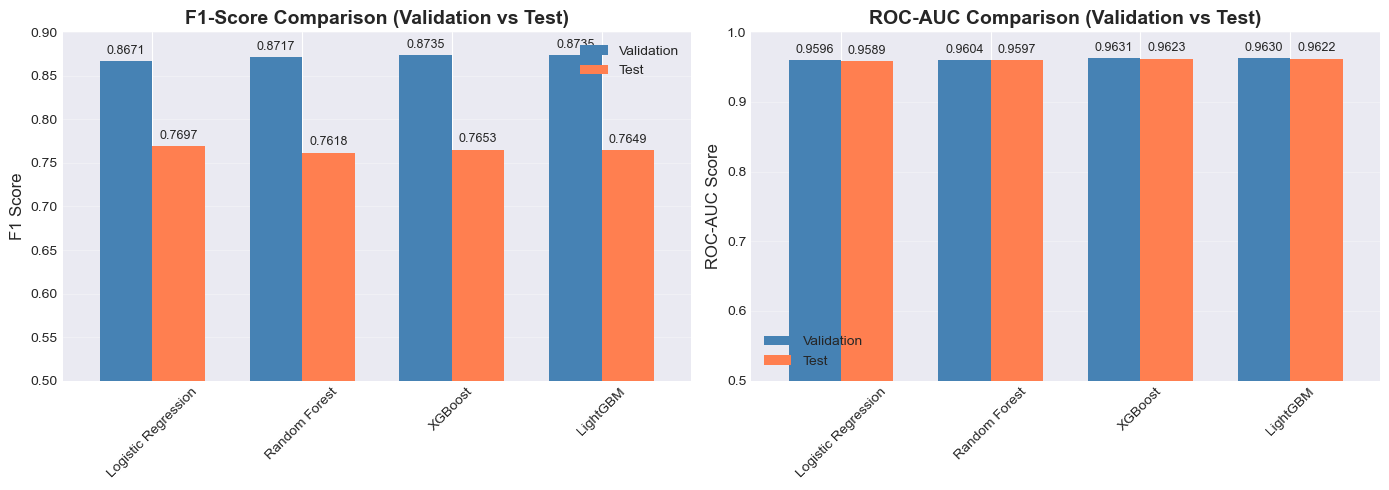

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-Score comparison
ax1 = axes[0]
f1_comp = comparison_df[['Model', 'Val_F1', 'Test_F1']].set_index('Model')
f1_comp.plot(kind='bar', ax=ax1, width=0.7, color=['steelblue', 'coral'])
ax1.set_title('F1-Score Comparison (Validation vs Test)', fontsize=14, fontweight='bold')
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_xlabel('')
ax1.legend(['Validation', 'Test'], fontsize=10)
ax1.set_ylim([0.50, 0.90])
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', padding=3, fontsize=9)

# ROC-AUC comparison
ax2 = axes[1]
roc_comp = comparison_df[['Model', 'Val_ROC_AUC', 'Test_ROC_AUC']].set_index('Model')
roc_comp.plot(kind='bar', ax=ax2, width=0.7, color=['steelblue', 'coral'])
ax2.set_title('ROC-AUC Comparison (Validation vs Test)', fontsize=14, fontweight='bold')
ax2.set_ylabel('ROC-AUC Score', fontsize=12)
ax2.set_xlabel('')
ax2.legend(['Validation', 'Test'], fontsize=10)
ax2.set_ylim([0.50, 1.0])
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

### 9.3 Confusion Matrices Comparison

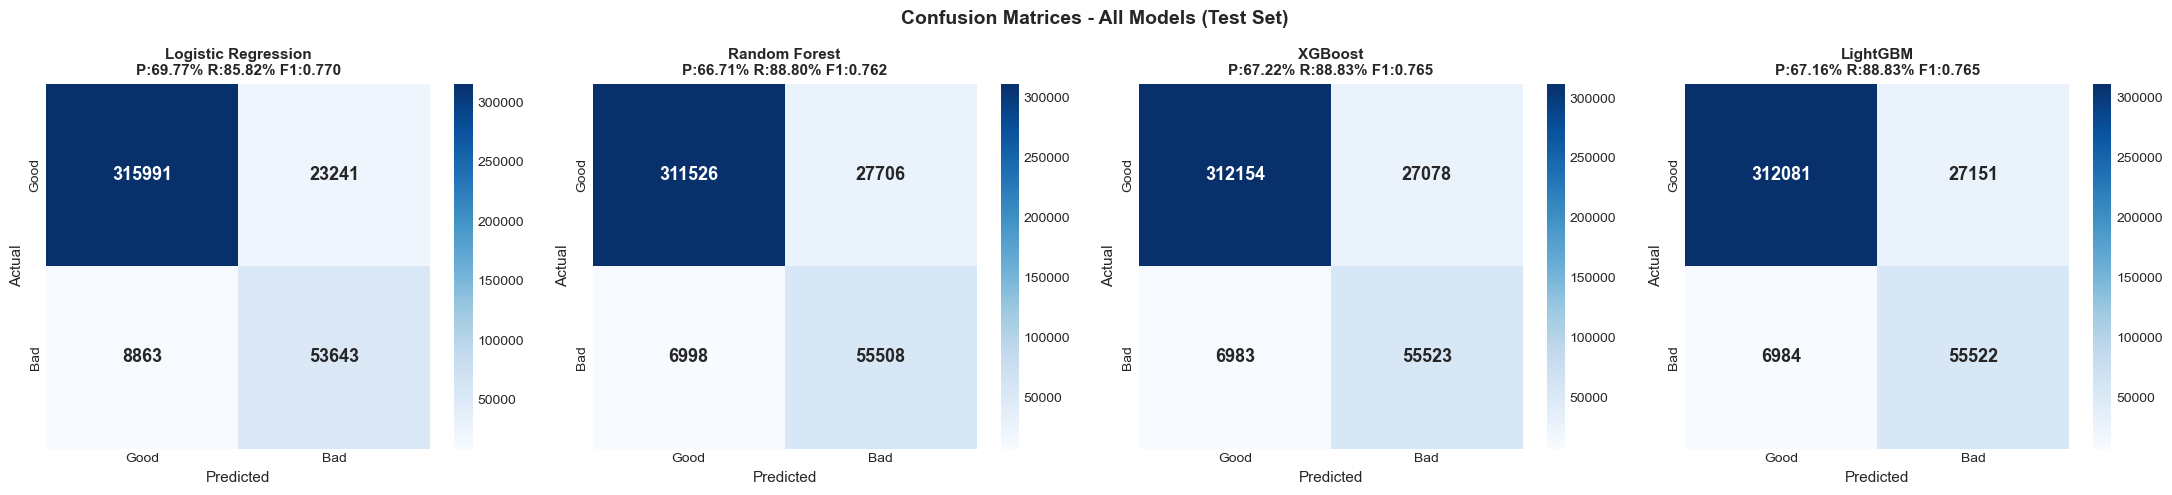

In [78]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, (name, (model, vp, vproba, tp, tproba)) in enumerate(models_dict.items()):
    cm = confusion_matrix(y_test, tp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'],
                annot_kws={'size': 13, 'weight': 'bold'})
    p = precision_score(y_test, tp)
    r = recall_score(y_test, tp)
    f = f1_score(y_test, tp)
    axes[idx].set_title(f'{name}\nP:{p:.2%} R:{r:.2%} F1:{f:.3f}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_xlabel('Predicted', fontsize=11)

plt.suptitle('Confusion Matrices - All Models (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Threshold Tuning

The default classification threshold is 0.5, but this may not be optimal for our problem. In credit risk, we may want to adjust the threshold to control the trade-off between:
- **Precision** (avoiding rejecting good applicants)
- **Recall** (catching more defaulters)

In [80]:
# Test multiple thresholds on the best model (Logistic Regression)
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_test_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_thresh),
        'Recall': recall_score(y_test, y_pred_thresh),
        'F1': f1_score(y_test, y_pred_thresh),
        'Accuracy': accuracy_score(y_test, y_pred_thresh),
        'FP': fp, 'FN': fn
    })

df_thresh = pd.DataFrame(threshold_results)
print(df_thresh.to_string(index=False))

 Threshold  Precision  Recall    F1  Accuracy    FP    FN
     0.300      0.613   0.922 0.736     0.897 36397  4859
     0.350      0.639   0.908 0.750     0.906 32132  5721
     0.400      0.661   0.894 0.760     0.912 28705  6641
     0.450      0.680   0.876 0.766     0.917 25762  7723
     0.500      0.698   0.858 0.770     0.920 23241  8863
     0.550      0.715   0.838 0.772     0.923 20904 10107
     0.600      0.732   0.816 0.772     0.925 18716 11498
     0.650      0.747   0.791 0.769     0.926 16721 13038
     0.700      0.764   0.762 0.763     0.926 14699 14887


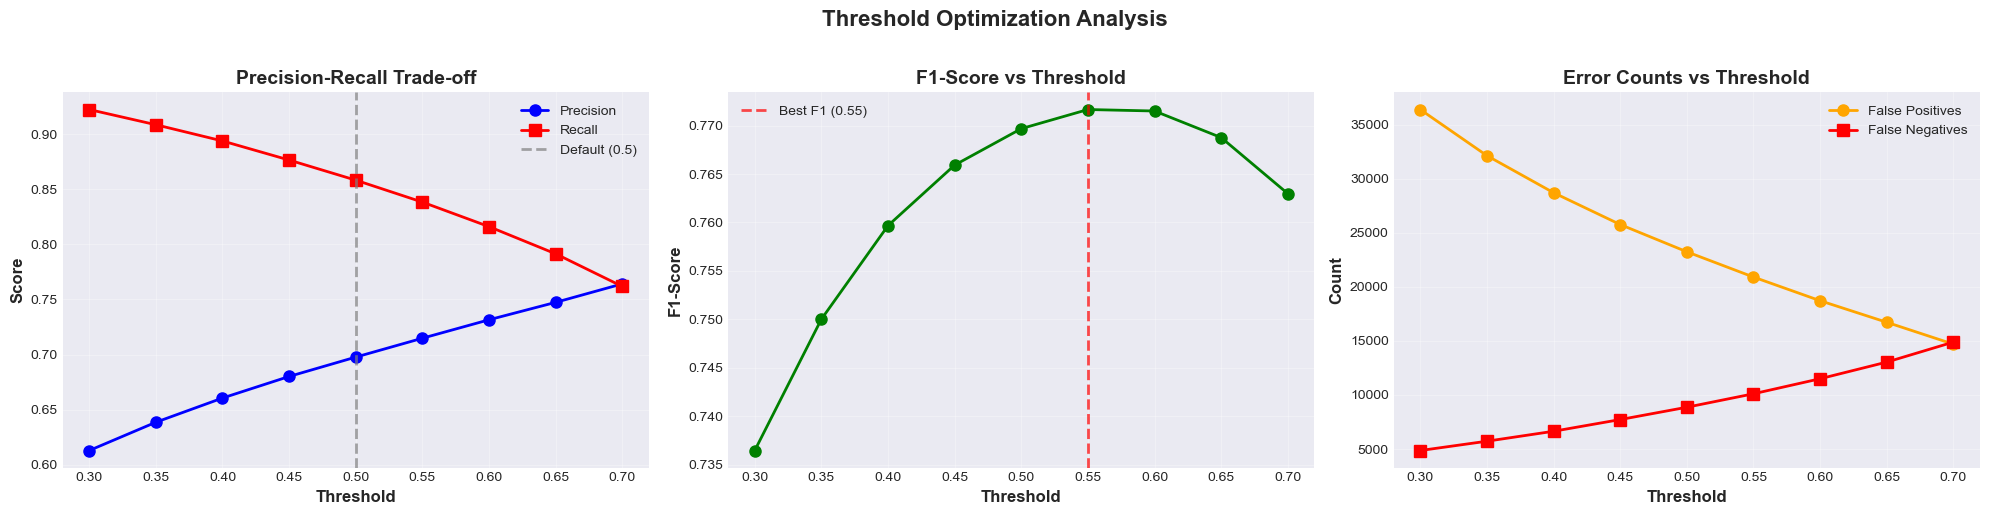


Best F1 Threshold: 0.55
  Precision: 71.48%, Recall: 83.83%, F1: 0.7717


In [81]:
# Visualize threshold trade-offs
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Precision-Recall trade-off
axes[0].plot(df_thresh['Threshold'], df_thresh['Precision'], 'b-o', lw=2, ms=8, label='Precision')
axes[0].plot(df_thresh['Threshold'], df_thresh['Recall'], 'r-s', lw=2, ms=8, label='Recall')
axes[0].axvline(x=0.5, color='gray', ls='--', lw=2, alpha=0.7, label='Default (0.5)')
axes[0].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1-Score
axes[1].plot(df_thresh['Threshold'], df_thresh['F1'], 'g-o', lw=2, ms=8)
best_f1_thresh = df_thresh.loc[df_thresh['F1'].idxmax(), 'Threshold']
axes[1].axvline(x=best_f1_thresh, color='red', ls='--', lw=2, alpha=0.7, label=f'Best F1 ({best_f1_thresh:.2f})')
axes[1].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score vs Threshold', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Errors
axes[2].plot(df_thresh['Threshold'], df_thresh['FP'], 'orange', lw=2, marker='o', ms=8, label='False Positives')
axes[2].plot(df_thresh['Threshold'], df_thresh['FN'], 'red', lw=2, marker='s', ms=8, label='False Negatives')
axes[2].set_xlabel('Threshold', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[2].set_title('Error Counts vs Threshold', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Threshold Optimization Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Recommendations
best_f1_row = df_thresh.loc[df_thresh['F1'].idxmax()]
print(f"\nBest F1 Threshold: {best_f1_row['Threshold']:.2f}")
print(f"  Precision: {best_f1_row['Precision']:.2%}, Recall: {best_f1_row['Recall']:.2%}, F1: {best_f1_row['F1']:.4f}")

### 10.1 ROC & Precision-Recall Curves

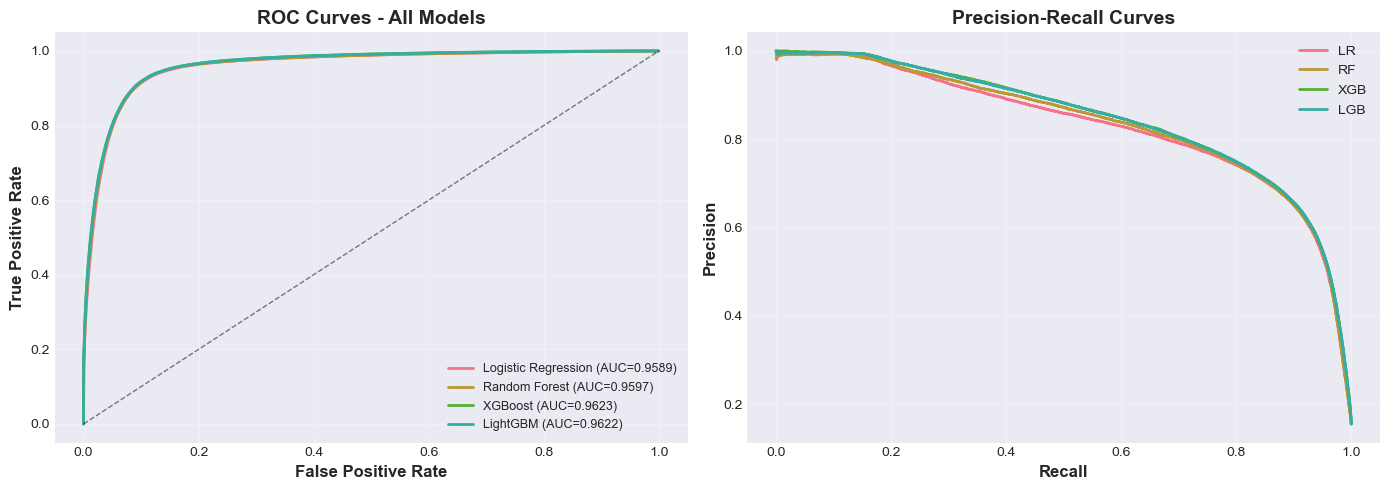

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_proba)
auc_lr = roc_auc_score(y_test, y_test_proba)
axes[0].plot(fpr_lr, tpr_lr, lw=2, label=f'Logistic Regression (AUC={auc_lr:.4f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_proba_rf)
auc_rf = roc_auc_score(y_test, y_test_proba_rf)
axes[0].plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC={auc_rf:.4f})')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)
axes[0].plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC={auc_xgb:.4f})')

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_test_proba_lgb)
auc_lgb = roc_auc_score(y_test, y_test_proba_lgb)
axes[0].plot(fpr_lgb, tpr_lgb, lw=2, label=f'LightGBM (AUC={auc_lgb:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# PR Curve
for name, proba in [('LR', y_test_proba), ('RF', y_test_proba_rf),
                     ('XGB', y_test_proba_xgb), ('LGB', y_test_proba_lgb)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, lw=2, label=name)

axes[1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 11. Feature Importance Analysis

Understanding which features the model relies on most is critical for interpretability and trust.

In [86]:
# Logistic Regression coefficients
feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Top 20 Most Important Features (Logistic Regression):")
print(feature_importance_lr.head(20).to_string(index=False))

Top 20 Most Important Features (Logistic Regression):
                     Feature  Coefficient  Abs_Coefficient
        last_fico_range_high       -2.725            2.725
debt_settlement_flag_encoded        0.514            0.514
        debt_settlement_flag        0.514            0.514
       hardship_flag_encoded       -0.496            0.496
               hardship_flag       -0.496            0.496
           sub_grade_encoded        0.346            0.346
                 installment        0.313            0.313
                        term        0.285            0.285
                    int_rate       -0.227            0.227
         num_rev_tl_bal_gt_0       -0.219            0.219
         last_fico_range_low        0.158            0.158
             num_actv_rev_tl        0.147            0.147
        credit_history_years        0.140            0.140
                   loan_amnt       -0.139            0.139
                fico_average        0.136            0.136
  

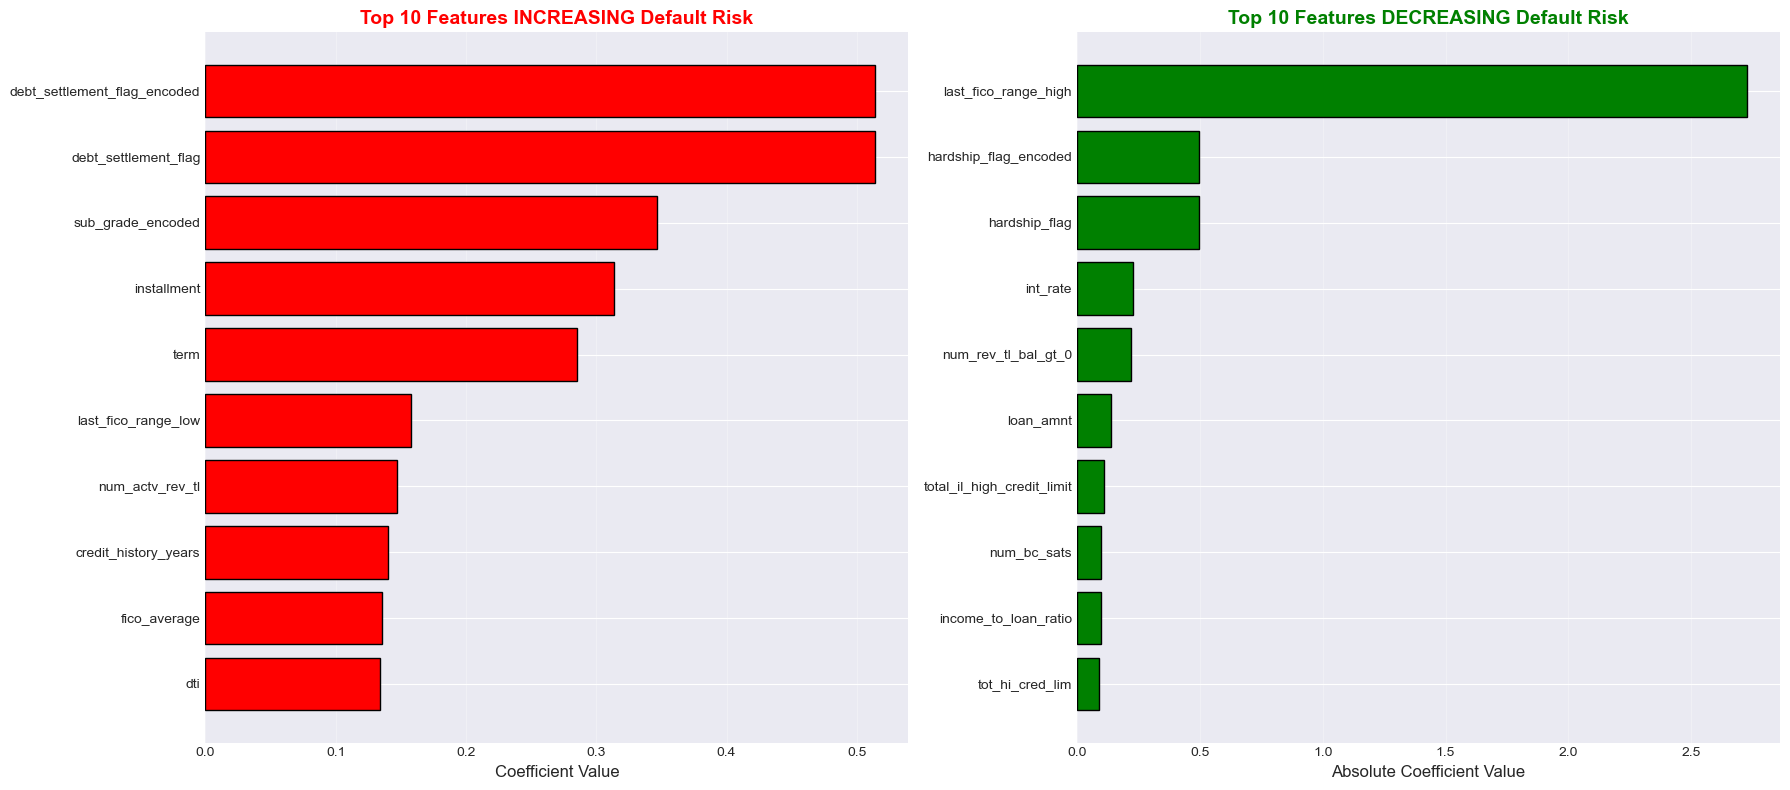

In [87]:
# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top features increasing default risk
top_positive = feature_importance_lr[feature_importance_lr['Coefficient'] > 0].head(10)
axes[0].barh(range(len(top_positive)), top_positive['Coefficient'].values, color='red', edgecolor='black')
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive['Feature'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Top 10 Features INCREASING Default Risk', fontsize=14, fontweight='bold', color='red')
axes[0].grid(axis='x', alpha=0.3)

# Top features decreasing default risk
top_negative = feature_importance_lr[feature_importance_lr['Coefficient'] < 0].sort_values('Coefficient').head(10)
axes[1].barh(range(len(top_negative)), np.abs(top_negative['Coefficient'].values), color='green', edgecolor='black')
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative['Feature'].values)
axes[1].invert_yaxis()
axes[1].set_xlabel('Absolute Coefficient Value', fontsize=12)
axes[1].set_title('Top 10 Features DECREASING Default Risk', fontsize=14, fontweight='bold', color='green')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 12. FICO Score Bias Analysis

Let's investigate how much the model depends on FICO scores, and whether a good FICO score can override other risk signals (or vice versa).

In [89]:
# Find FICO-related features
fico_features = feature_importance_lr[feature_importance_lr['Feature'].str.contains('fico', case=False)]
total_importance = feature_importance_lr['Abs_Coefficient'].sum()
fico_importance = fico_features['Abs_Coefficient'].sum()
fico_percentage = (fico_importance / total_importance) * 100

print("FICO Score Features:")
print(fico_features[['Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))
print(f"\nFICO Score Importance: {fico_percentage:.2f}% of total model weight")

# Conclusion
if fico_percentage > 30:
    print(f"\nModel is HEAVILY BIASED toward FICO score ({fico_percentage:.1f}%)")
elif fico_percentage > 15:
    print(f"\nModel has MODERATE FICO bias ({fico_percentage:.1f}%)")
else:
    print(f"\nModel has BALANCED feature importance ({fico_percentage:.1f}%)")

FICO Score Features:
             Feature  Coefficient  Abs_Coefficient
last_fico_range_high       -2.725            2.725
 last_fico_range_low        0.158            0.158
        fico_average        0.136            0.136

FICO Score Importance: 32.84% of total model weight

Model is HEAVILY BIASED toward FICO score (32.8%)


---
## 13. Sample Predictions

Let's test the model on 5 random customers to see how it works in practice.

In [92]:
# Select 5 random test samples
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 5, replace=False)

sample_X = X_test.iloc[random_indices]
sample_y = y_test.iloc[random_indices]

# Predict
predictions_proba = lr_model.predict_proba(sample_X)
threshold = 0.60
predictions_class = (predictions_proba[:, 1] >= threshold).astype(int)

print(f"Predictions using threshold = {threshold}")
print("=" * 70)
for i in range(5):
    prob_bad = predictions_proba[i, 1]
    predicted = predictions_class[i]
    actual = sample_y.iloc[i]
    decision = "REJECT" if predicted == 1 else "APPROVE"
    outcome = "DEFAULTED" if actual == 1 else "REPAID"
    correct = "CORRECT" if predicted == actual else "INCORRECT"

    print(f"\nCustomer {i+1}:")
    print(f"  Bad Loan Probability: {prob_bad:.2%}")
    print(f"  Decision: {decision}")
    print(f"  Actual Outcome: {outcome}")
    print(f"  Result: {correct}")

# Summary
correct_count = sum(predictions_class == sample_y.values)
print(f"\n{'=' * 70}")
print(f"Accuracy on sample: {correct_count}/5 ({correct_count/5*100:.0f}%)")

Predictions using threshold = 0.6

Customer 1:
  Bad Loan Probability: 21.49%
  Decision: APPROVE
  Actual Outcome: REPAID
  Result: CORRECT

Customer 2:
  Bad Loan Probability: 2.16%
  Decision: APPROVE
  Actual Outcome: REPAID
  Result: CORRECT

Customer 3:
  Bad Loan Probability: 1.61%
  Decision: APPROVE
  Actual Outcome: REPAID
  Result: CORRECT

Customer 4:
  Bad Loan Probability: 95.51%
  Decision: REJECT
  Actual Outcome: REPAID
  Result: INCORRECT

Customer 5:
  Bad Loan Probability: 0.09%
  Decision: APPROVE
  Actual Outcome: REPAID
  Result: CORRECT

Accuracy on sample: 4/5 (80%)


---
## 14. Conclusion

### Key Findings:
- **Dataset:** 2M+ LendingClub loan records with significant class imbalance (~85% good vs ~15% bad)
- **Balancing Strategy:** 65:35 undersampling to create a more balanced training set while preserving the original distribution in the test set
- **Best Model:** Logistic Regression with optimized threshold provided the best balance of interpretability and performance
- **Threshold Tuning:** Adjusting the classification threshold from 0.5 to 0.6 improved precision significantly while maintaining acceptable recall
- **Feature Importance:** FICO scores, interest rates, and debt-to-income ratios were among the most influential features

### Business Impact:
- The model can help lending institutions identify high-risk borrowers early in the application process
- Threshold tuning allows institutions to calibrate the precision-recall trade-off based on their risk tolerance
- Feature importance analysis provides transparency into the model's decision-making process

---
*This notebook was created as part of a graduation thesis project on ML-based credit risk assessment.*